# Wstęp i definicja problemu

## Cel symulacji
Celem badania jest odpowiedź na pytanie: **Jak parametry geometryczne początkowego wypiętrzenia wody na otwartym oceanie wpływają na ewolucję fali tsunami wchodzącej na szelf kontynentalny?**
Badanie symuluje sytuację, w której fala o dużej energii dociera do linii brzegowej (plaży), weryfikując, który parametr jest krytyczny dla wysokości fali uderzeniowej: jej wysokość początkowa czy długość (szerokość).

## Opis układu i parametry fizyczne
Symulację przeprowadzono w kanale wodnym o wymiarach $300 \times 40$ m.

* **Fizyka:** Zastosowano Równania Płytkiej Wody, rozwiązywane solwerem **PyMPDATA**.
* **Batymetria:**
    * $x \in [0, 150]$ m: Dno płaskie ($h_0 = 4.0$ m).
    * $x \in [150, 300]$ m: Liniowy wznios dna (szelf) od $4.0$ m aż do **$0$ m** (linia brzegowa).
* **Warunek początkowy:** Stan spoczynku zaburzony falą Gaussa o zadanej amplitudzie $A$ i szerokości $\sigma$.
* **Czas symulacji:** $N_t = 350$ kroków (ok. 35 s), co pozwala uchwycić moment dynamicznego wejścia fali na ląd.

In [5]:
%config InlineBackend.figure_formats = ['svg']
import numpy as np
from matplotlib import pyplot
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions


In [6]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray,bathymetry:np.ndarray=None, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        self.bathymetry = bathymetry
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid)
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid),
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }
    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)
    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)
        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1
    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

In [7]:
def run_experiment(amplituda, szerokosc, tytul, nazwa_pliku):
    """
    Uruchamia symulację, rysuje wynik i zapisuje do PDF.
    """    
    grid = (300, 40)
    x_granica = 150
    profil_dna = np.concatenate([np.full(x_granica, 4.0), np.linspace(4.0, 0, grid[0] - x_granica)])
    bathymetry = np.tile(profil_dna[:, np.newaxis], (1, grid[1]))

    zeta = np.zeros(grid, dtype=float)
    xx, yy = np.meshgrid(np.arange(grid[0]), np.arange(grid[1]), indexing='ij')
    dist_sq = (xx - 50)**2 + (yy - 20)**2
    zeta = amplituda * np.exp(-dist_sq / (2 * szerokosc**2))

    h_initial = bathymetry + zeta

    solver = ShallowWaterEquationsIntegrator(h_initial=h_initial, bathymetry=bathymetry)
    output = solver(nt=350, g=9.81, dt_over_dxy=(0.1, 0.1), outfreq=350)
    
    psi = output['h'][-1]
    h_rest = bathymetry
    elevation = psi - h_rest
    bottom = -h_rest
    
    xi, yi = np.indices(psi.shape)
    mid_y = psi.shape[1] // 2
    
    fig, (ax1, ax2) = pyplot.subplots(2, 1, figsize=(7, 6), 
                                      gridspec_kw={'height_ratios': [3, 1]},
                                      subplot_kw={'projection': '3d'})
    
    ax1.plot_wireframe(xi, yi, elevation, rstride=5, cstride=5, color='blue', linewidth=0.6)
    ax1.plot_surface(xi, yi, bottom, rstride=5, cstride=5, cmap='gist_earth', alpha=0.4, linewidth=0, antialiased=False)
    
    ax1.set_title(f"WIDOK 3D: {tytul}", fontsize=14)
    ax1.set_zlim(-4, 2)
    ax1.set_xlabel("Ogległość [m]")
    ax1.set_zlabel("Wysokość [m]")
    ax1.set_ylabel("Szerokość [m]")
    ax1.view_init(elev=30, azim=-80)

    ax2.remove()
    ax2 = fig.add_subplot(2, 1, 2)
    ax2.fill_between(np.arange(grid[0]), -5, bottom[:, mid_y], color='tan', alpha=0.5, label='Dno')
    ax2.plot(bottom[:, mid_y], 'k-', linewidth=1)
    ax2.plot(elevation[:, mid_y], 'b-', linewidth=2, label='Fala')
    
    ax2.set_ylim(-5, 3)
    ax2.set_xlim(0, 300)
    ax2.set_title("PRZEKRÓJ BOCZNY: Profil fali przy brzegu")
    ax2.set_ylabel("Wysokość [m]")
    ax2.set_xlabel("Ogległość [m]")
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower right')
    
    max_h = np.max(elevation[:, mid_y])
    ax2.text(0.02, 0.85, f"Max Wysokość: {max_h:.4f}m", transform=ax2.transAxes, fontsize=10)
    
    pyplot.tight_layout()

    pyplot.savefig(nazwa_pliku) 
    pyplot.show()
    
    return output

# Analiza Zbieżności (Numeryka)

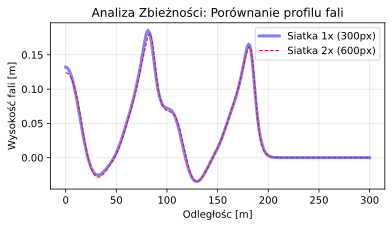

In [8]:
def get_setup(scale=1):
    nx, ny = 300 * scale, 40 * scale
    x_granica = nx // 2
    profil = np.concatenate([np.full(x_granica, 4.0), np.linspace(4.0, 0, nx - x_granica)])
    b = np.tile(profil[:, np.newaxis], (1, ny))
    
    xx, yy = np.meshgrid(np.arange(nx), np.arange(ny), indexing='ij')
    dist_sq = (xx - 50*scale)**2 + (yy - 20*scale)**2
    z = 0.5 * np.exp(-dist_sq / (2 * (10.0*scale)**2))
    return b + z, b

h_init_1, b_1 = get_setup(1)
res1 = ShallowWaterEquationsIntegrator(h_initial=h_init_1, bathymetry=b_1)(nt=200, g=9.81, dt_over_dxy=(0.1, 0.1), outfreq=200)

h_init_2, b_2 = get_setup(2)
res2 = ShallowWaterEquationsIntegrator(h_initial=h_init_2, bathymetry=b_2)(nt=400, g=9.81, dt_over_dxy=(0.1, 0.1), outfreq=400)

fig_conv = pyplot.figure(figsize=(6, 3))
ax_conv = fig_conv.add_subplot(1, 1, 1)

wave1 = res1['h'][-1][:, 20] - b_1[:, 20]
wave2 = res2['h'][-1][:, 40] - b_2[:, 40]

ax_conv.plot(np.linspace(0, 300, len(wave1)), wave1, 'b-', lw=3, alpha=0.5, label='Siatka 1x (300px)')
ax_conv.plot(np.linspace(0, 300, len(wave2)), wave2, 'r--', lw=1, label='Siatka 2x (600px)')

ax_conv.set_title("Analiza Zbieżności: Porównanie profilu fali")
ax_conv.set_xlabel("Odległośc [m]")
ax_conv.set_ylabel("Wysokość fali [m]")
ax_conv.legend()
ax_conv.grid(True, alpha=0.3)

pyplot.savefig("analiza_zbieznosci.pdf")
pyplot.show()

W celu weryfikacji poprawności rozwiązania przeprowadzono test zbieżności (wykres powyżej). Porównano profil fali dla:

* **Siatki bazowej ($1\times$):** 300 węzłów w osi X.
* **Siatki zagęszczonej ($2\times$):** 600 węzłów w osi X.

**Wnioski z analizy zbieżności:**
Profile fali dla obu rozdzielczości pokrywają się niemal idealnie. Brak widocznych różnic w fazie i amplitudzie fali świadczy o tym, że rozwiązanie na siatce 300px jest **zbieżne numerycznie**. Nie obserwuje się istotnej dyssypacji numerycznej, która wymagałaby stosowania gęstszej siatki. Przyjęta rozdzielczość jest wystarczająca do dalszych badań fizycznych.

# Wyniki symulacji i Dyskusja

Przeprowadzono trzy symulacje dla fal o wysokiej energii, badając zachowanie przy wyjściu na ląd.

**Scenariusz BAZOWY ($A=1.0, \sigma=20$):**

* Fala o znacznej wysokości i średniej szerokości.
* **Max wysokość przy brzegu:** **0.7750 m**.

**Scenariusz SZEROKA ($A=1.0, \sigma=40$):**

* Podwojona szerokość fali przy tej samej amplitudzie co w bazie.
* **Max wysokość przy brzegu:** **0.6538 m**.

**Scenariusz WYSOKA ($A=2.0, \sigma=20$):**

* Podwojona amplituda przy tej samej szerokości co w bazie.
* **Max wysokość przy brzegu:** **1.8042 m**.

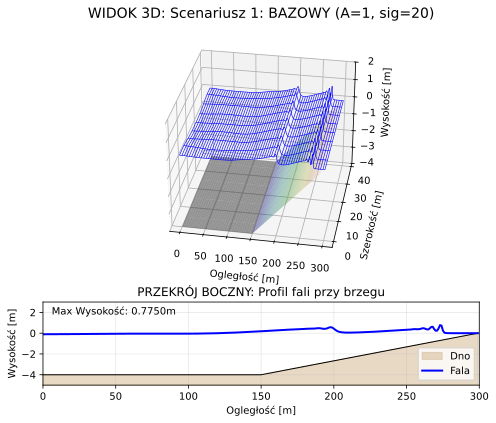

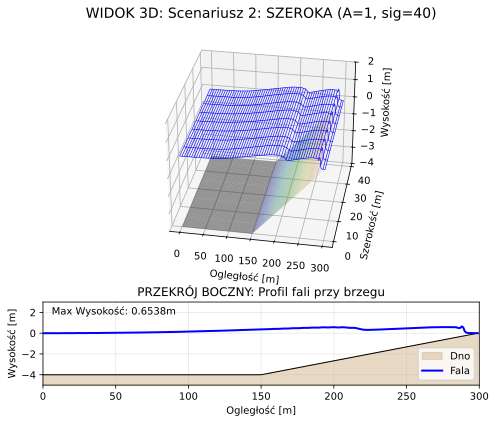

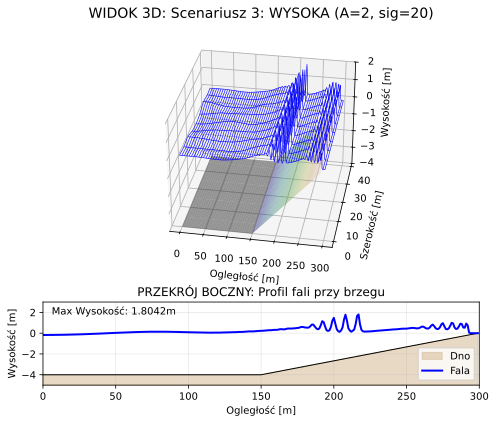

In [9]:
out1 = run_experiment(amplituda=1, szerokosc=20.0, 
                      tytul="Scenariusz 1: BAZOWY (A=1, sig=20)", 
                      nazwa_pliku="scenariusz_1.pdf")
out2 = run_experiment(amplituda=1, szerokosc=40.0, 
                      tytul="Scenariusz 2: SZEROKA (A=1, sig=40)", 
                      nazwa_pliku="scenariusz_2.pdf")
out3 = run_experiment(amplituda=2, szerokosc=20.0, 
                      tytul="Scenariusz 3: WYSOKA (A=2, sig=20)", 
                      nazwa_pliku="scenariusz_3.pdf")

## Interpretacja i Wnioski
Analiza porównawcza prowadzi do następujących obserwacji:

*  **Dominacja Amplitudy ($A$):** Największy wpływ na wynik końcowy miała amplituda początkowa. Podwojenie wysokości fali (Scenariusz 1 $\to$ 3) spowodowało wzrost spiętrzenia z $0.78$ m do aż $1.80$ m. Jest to wzrost **ponad 2.3-krotny**, co świadczy o silnie nieliniowym charakterze zjawiska przy dużych amplitudach (energia fali rośnie z kwadratem amplitudy).
* **Zachowanie fali szerokiej ($\sigma$):** W tym konkretnym przypadku fala szersza (Scenariusz 2) osiągnęła *niższy* pik maksymalny ($0.65$ m) niż fala bazowa ($0.78$ m). Wynika to z mniejszej stromości zbocza fali szerokiej – woda podnosi się łagodniej, przez co efekt gwałtownego spiętrzenia jest mniej dynamiczny w chwili uderzenia w brzeg w porównaniu do bardziej stromej fali węższej.
* **Wniosek końcowy:** W przypadku fal uderzeniowych wchodzących na plażę, najbardziej niszczycielski potencjał (w sensie maksymalnej wysokości słupa wody) wykazują fale o **dużej amplitudzie początkowej**. Choć fala szeroka niesie ogromną objętość wody, jej łagodniejszy profil może skutkować niższym chwilowym maksimum spiętrzenia.

# Analiza pola prędkości

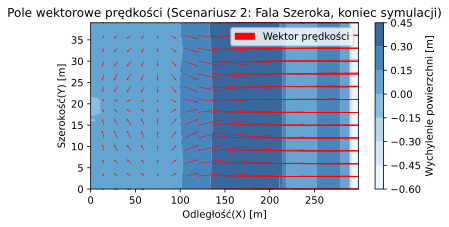

In [10]:
grid = (300, 40)
x_granica = 150
profil_dna = np.concatenate([np.full(x_granica, 4.0), np.linspace(4.0, 0.5, grid[0] - x_granica)])
bathymetry = np.tile(profil_dna[:, np.newaxis], (1, grid[1]))

frame_idx = -1
h = out2['h'][frame_idx]
uh = out2['uh'][frame_idx]
vh = out2['vh'][frame_idx]

u = np.divide(uh, h, where=h>0.01)
v = np.divide(vh, h, where=h>0.01)

fig_vec = pyplot.figure(figsize=(6, 3))
ax_vec = fig_vec.add_subplot(1, 1, 1)

X, Y = np.meshgrid(np.arange(h.shape[0]), np.arange(h.shape[1]), indexing='ij')

elevation = h - bathymetry
c = ax_vec.contourf(X, Y, elevation, cmap='Blues', alpha=0.8)
pyplot.colorbar(c, label='Wychylenie powierzchni [m]')

skip = (slice(None, None, 15), slice(None, None, 3))

ax_vec.quiver(X[skip], Y[skip], u[skip], v[skip], 
              color='red', scale=2, width=0.002, label='Wektor prędkości')

ax_vec.set_title("Pole wektorowe prędkości (Scenariusz 2: Fala Szeroka, koniec symulacji)")
ax_vec.set_xlabel("Odległość(X) [m]")
ax_vec.set_ylabel("Szerokość(Y) [m]")
ax_vec.legend(loc='upper right')

pyplot.savefig("pole_predkosci.pdf")
pyplot.show()

Powyższa wizualizacja przedstawia pole prędkości dla Scenariusza 2 (Fala Szeroka, $\sigma=40$) w chwili $t=350$.

* **Analiza:** Mapa ukazuje silny przepływ wody skierowany w stronę brzegu (wzdłuż osi X, czerwone wektory).
* **Fizyka:** Największe prędkości występują w obszarze czoła fali, gdzie gradient poziomu wody jest największy. Mimo że fala ta ma mniejszy pik wysokości niż scenariusz "Wysoki", pole prędkości obejmuje bardzo duży obszar, co potwierdza, że fala szeroka transportuje znaczną masę wody w głąb strefy przybrzeżnej, nawet jeśli robi to mniej gwałtownie w pionie.